# NB09 — Ejemplos visuales de mamografía por categoría BI-RADS

**TFM · Máster Universitario en Inteligencia Artificial · VIU 2025-2026 · Víctor Rodríguez Rodríguez**

---

## Propósito
Generar dos figuras ilustrativas:

- Figura 1×5 con un ejemplo real de cada categoría BI-RADS (1 a 5), con bounding box superpuesto en las categorías sospechosas (4 y 5).
- Panel 2×2 con las cuatro vistas estándar de un examen de mamografía de cribado (L-CC, R-CC, L-MLO, R-MLO).

Los ejemplos se seleccionan del propio dataset VinDr-Mammo (cohorte vietnamita) para que las condiciones de cohorte y resolución sean las mismas que las del trabajo experimental.

**Inputs**: `Data/vindr-mammo/breast-level_annotations.csv`, `Data/vindr-mammo/finding_annotations.csv`, DICOMs en `Data/vindr-mammo/images/`.

**Outputs**: `outputs/Features/ejemplos_birads.png`, `outputs/Features/mamografia_4_vistas.png`.


## 1. Setup y paths


In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BASE = os.environ.get('TFM_PROJECT_ROOT',os.path.abspath(os.path.join(os.getcwd(), '..')))
DATA = os.path.join(BASE, 'Data', 'vindr-mammo')
IMG_DIR = os.path.join(DATA, 'images')
BREAST_CSV = os.path.join(DATA, 'breast-level_annotations.csv')
FINDING_CSV = os.path.join(DATA, 'finding_annotations.csv')
OUT_DIR = os.path.join(BASE, 'outputs', 'Features')
os.makedirs(OUT_DIR, exist_ok=True)

print(f'BASE: {BASE}')
print(f'IMG_DIR: {IMG_DIR}')


BASE: c:\Users\victo\Documents\TFM\Proyecto
IMG_DIR: c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images


## 2. Cargar anotaciones y seleccionar ejemplos

Se elige una vista **CC** representativa para cada categoría BI-RADS (1-5). Para las categorías 4 y 5 se selecciona una vista con **bounding box del hallazgo** disponible en `finding_annotations.csv`.


In [2]:
breast = pd.read_csv(BREAST_CSV)
finding = pd.read_csv(FINDING_CSV)

def parse_birads(v):
    if isinstance(v, str):
        return int(v.replace('BI-RADS', '').strip())
    return int(v) if not pd.isna(v) else None

breast['birads_num'] = breast['breast_birads'].apply(parse_birads)
finding['birads_num'] = finding['breast_birads'].apply(parse_birads)

np.random.seed(42)

# Para BI-RADS 1-3: elegir la primera vista CC disponible
# Para BI-RADS 4-5: elegir la primera con bounding box en finding_annotations
ejemplos = []
for b in [1, 2, 3, 4, 5]:
    if b <= 3:
        cand = breast[(breast.birads_num == b) & (breast.view_position == 'CC')].reset_index(drop=True)
        row = cand.iloc[0]
        ejemplos.append({
            'birads': b,
            'image_id': row['image_id'],
            'study_id': row['study_id'],
            'laterality': row['laterality'],
            'view': row['view_position'],
            'density': row['breast_density'].replace('DENSITY ', ''),
            'bbox': None,
        })
    else:
        cand = finding[(finding.birads_num == b) & (finding.view_position == 'CC') & finding['xmin'].notna()].reset_index(drop=True)
        row = cand.iloc[0]
        ejemplos.append({
            'birads': b,
            'image_id': row['image_id'],
            'study_id': row['study_id'],
            'laterality': row['laterality'],
            'view': row['view_position'],
            'density': row['breast_density'].replace('DENSITY ', ''),
            'bbox': (row['xmin'], row['ymin'], row['xmax'], row['ymax']),
            'finding_cat': row['finding_categories'],
        })

print('Ejemplos seleccionados:')
print(f'{"BI-RADS":<10}{"Lat":<5}{"Vista":<7}{"Dens":<6}{"BBox":<8}{"Study ID (first 12)"}')
print('-' * 65)
for e in ejemplos:
    has_bbox = 'OK' if e['bbox'] is not None else '-'
    print(f'{e["birads"]:<10}{e["laterality"]:<5}{e["view"]:<7}{e["density"]:<6}{has_bbox:<8}{e["study_id"][:12]}...')


Ejemplos seleccionados:
BI-RADS   Lat  Vista  Dens  BBox    Study ID (first 12)
-----------------------------------------------------------------
1         L    CC     C     -       8269f5971eac...
2         L    CC     C     -       b8d273e8601f...
3         L    CC     C     -       cca141f804a8...
4         R    CC     C     OK      48575a27b7c9...
5         L    CC     C     OK      57674c2def92...


## 3. Función de carga DICOM para visualización

Preparación mínima para mostrar la imagen: leer DICOM, aplicar RescaleSlope/Intercept, Window/Level e invertir MONOCHROME1 si es necesario. **No** se aplica alineación por centroide ni redimensionado — queremos mostrar la mamografía tal como la vería el radiólogo.

In [3]:
def load_dicom_for_display(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    px = ds.pixel_array.astype(np.float32)
    px = px * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0]) if hasattr(ds.WindowCenter, '__iter__') else float(ds.WindowCenter)
        ww = float(ds.WindowWidth[0])  if hasattr(ds.WindowWidth,  '__iter__') else float(ds.WindowWidth)
        px = np.clip(px, wc-ww/2, wc+ww/2)
    
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        px = px.max() - px
    
    return px


## 4. Figura 1×5 con los ejemplos

Para cada categoría BI-RADS se muestra la vista CC seleccionada. En las categorías 4 y 5 se superpone el bounding box del hallazgo (`finding_annotations.csv`) para señalar la región sospechosa.

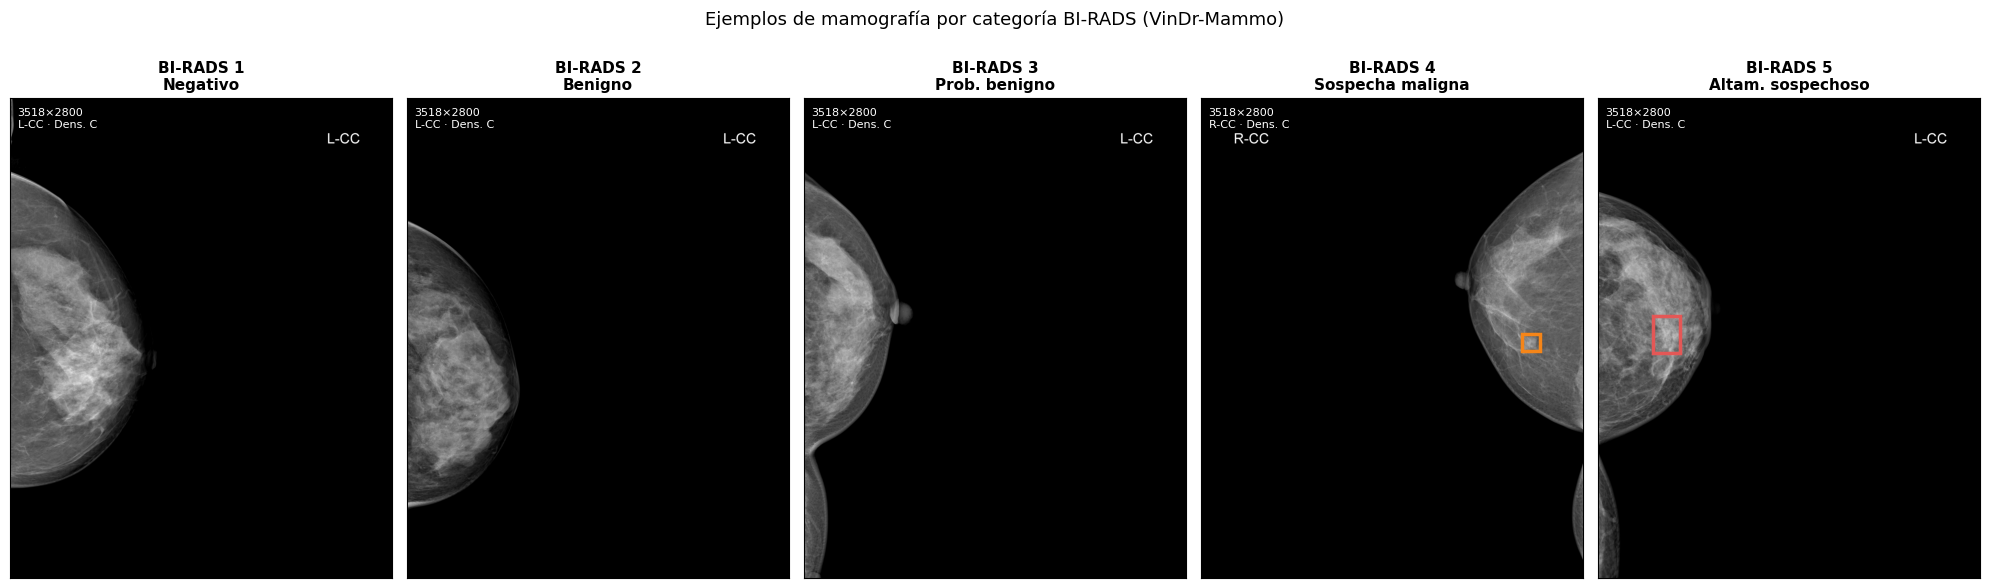


Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Features\ejemplos_birads.png


In [4]:
def _dcm_path(study_id, image_id):
    return os.path.join(IMG_DIR, study_id, f'{image_id}.dicom')

# Estilos por categoría
_bir_titulos = {
    1: 'BI-RADS 1\nNegativo',
    2: 'BI-RADS 2\nBenigno',
    3: 'BI-RADS 3\nProb. benigno',
    4: 'BI-RADS 4\nSospecha maligna',
    5: 'BI-RADS 5\nAltam. sospechoso',
}
_bbox_color = {4: '#f58518', 5: '#e45756'}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, e in zip(axes, ejemplos):
    path = _dcm_path(e['study_id'], e['image_id'])
    if not os.path.exists(path):
        ax.text(0.5, 0.5, f'DICOM no encontrado:\n{path[-40:]}', ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_title(_bir_titulos[e['birads']], fontsize=11, fontweight='bold')
        ax.axis('off')
        continue
    
    img = load_dicom_for_display(path)
    ax.imshow(img, cmap='gray', aspect='equal')
    
    # Bounding box para BI-RADS 4 y 5
    if e['bbox'] is not None:
        xmin, ymin, xmax, ymax = e['bbox']
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2.5, edgecolor=_bbox_color[e['birads']], facecolor='none')
        ax.add_patch(rect)
    
    ax.set_title(_bir_titulos[e['birads']], fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    
    # Shape + laterality/densidad
    txt = f'{img.shape[0]}×{img.shape[1]}\n{e["laterality"]}-{e["view"]} · Dens. {e["density"]}'
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=8, va='top', ha='left', color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7, edgecolor='none'))

fig.suptitle('Ejemplos de mamografía por categoría BI-RADS (VinDr-Mammo)', fontsize=13, y=1.02)
plt.tight_layout()

_out_path = os.path.join(OUT_DIR, 'ejemplos_birads.png')
plt.savefig(_out_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'\nGuardado: {_out_path}')


## Nota

Los recuadros de colores señalan la localización de los hallazgos anotados por los radiólogos de VinDr-Mammo en las categorías sospechosas (naranja para BI-RADS 4, rojo para BI-RADS 5). En las categorías 1-3 no hay hallazgos anotados por definición (BI-RADS 1 = negativo, 2 = benigno, 3 = probablemente benigno), por lo que no hay bounding box que mostrar.

## 5. Panel de las 4 vistas estándar de una mamografía

Esta sección genera una figura ilustrativa con las cuatro proyecciones estándar de un examen de mamografía de cribado (L-CC, R-CC, L-MLO, R-MLO) para acompañar la explicación textual del capítulo 3.1.2 del TFM.

**Criterios de selección del estudio ilustrativo:**

- Las cuatro vistas presentes en el DICOM del estudio.
- BI-RADS 1 en las cuatro (examen negativo típico), para no distraer con hallazgos.
- Densidad C, que es la categoría dominante en VinDr-Mammo (76,5 % de las vistas) y por tanto la más representativa de la cohorte.
- Semilla fija (42) para reproducibilidad.

Estudios candidatos (4 vistas · BI-RADS 1 · densidad C): 1867
Estudio seleccionado: 0025a5dc99fd5c742026f0b2b030d3e9
  L-CC: 451562831387...
  L-MLO: 2ddfad7286c2...
  R-CC: fcf12c2803ba...
  R-MLO: 47c8858666bc...


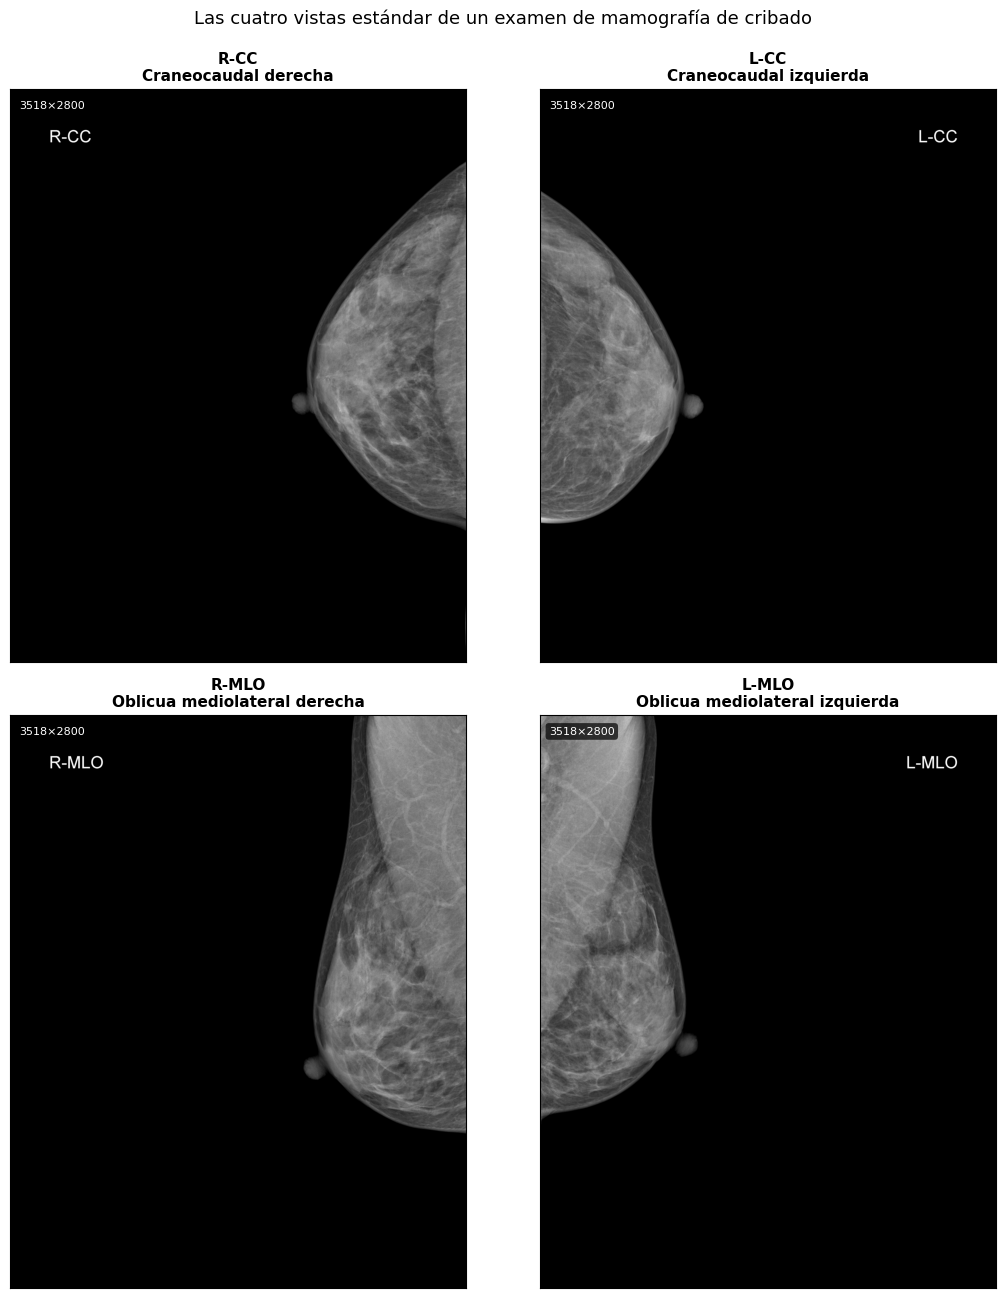


Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Features\mamografia_4_vistas.png


In [5]:
np.random.seed(42)

VISTAS_REQUERIDAS = {('R', 'CC'), ('L', 'CC'), ('R', 'MLO'), ('L', 'MLO')}

# Estudios con todas las mamas BI-RADS 1 y densidad C
_cand = breast[(breast.birads_num == 1) & (breast.breast_density == 'DENSITY C')].copy()

# Requerir que las 4 combinaciones (lat, view) estén presentes en el estudio
def _tiene_4_vistas(g):
    return set(zip(g['laterality'], g['view_position'])) >= VISTAS_REQUERIDAS

_estudios_ok = _cand.groupby('study_id').filter(_tiene_4_vistas)
_ids = sorted(_estudios_ok['study_id'].unique())
print(f'Estudios candidatos (4 vistas · BI-RADS 1 · densidad C): {len(_ids)}')

study_id = _ids[0]  # elegimos el primero por orden alfabético
print(f'Estudio seleccionado: {study_id}')

# Recuperar las 4 vistas de ese estudio
_sub = _estudios_ok[_estudios_ok.study_id == study_id]
vistas_4 = {}
for _, row in _sub.iterrows():
    key = (row['laterality'], row['view_position'])
    if key in VISTAS_REQUERIDAS and key not in vistas_4:
        vistas_4[key] = row['image_id']

for k, v in vistas_4.items():
    print(f'  {k[0]}-{k[1]}: {v[:12]}...')

_ORDEN = [
    (('R', 'CC'), 'R-CC', 'Craneocaudal derecha'),
    (('L', 'CC'), 'L-CC', 'Craneocaudal izquierda'),
    (('R', 'MLO'), 'R-MLO', 'Oblicua mediolateral derecha'),
    (('L', 'MLO'), 'L-MLO', 'Oblicua mediolateral izquierda'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 13))
for ax, (key, corto, largo) in zip(axes.flat, _ORDEN):
    image_id = vistas_4[key]
    path = _dcm_path(study_id, image_id)
    img = load_dicom_for_display(path)
    ax.imshow(img, cmap='gray', aspect='equal')
    ax.set_title(f'{corto}\n{largo}', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    # Anotación con dimensiones para trazabilidad
    ax.text(0.02, 0.98, f'{img.shape[0]}×{img.shape[1]}', transform=ax.transAxes, fontsize=8, va='top', ha='left', color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7, edgecolor='none'))

fig.suptitle('Las cuatro vistas estándar de un examen de mamografía de cribado', fontsize=13, y=0.995)
plt.tight_layout()

_out_path = os.path.join(OUT_DIR, 'mamografia_4_vistas.png')
plt.savefig(_out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\nGuardado: {_out_path}')